
INITIAL MEMORY CONFIGURATION
Block_no	Status	Block_size
B1	USED	-
B2	FREE	55
B3	USED	-
B4	FREE	27
B5	FREE	46
B6	USED	-
B7	USED	-
B8	FREE	39
B9	USED	-
B10	FREE	35
B11	USED	-
B12	FREE	41
B13	FREE	36
B14	FREE	43
B15	USED	-
B16	USED	-
B17	FREE	12
B18	FREE	44
B19	FREE	31
B20	USED	-

FILE SIZES
File_no  File_size
P1	7
P2	8
P3	18
P4	28
P5	9

====== MEMORY ALLOCATION MENU ======
1. First Fit
2. Best Fit
3. Worst Fit
4. Exit

Allocation using first FIT
File_no  File_size  Block_no  Block_size  Fragment
1	7	B255	48
2	8	B427	19
3	18	B546	28
4	28	B839	11
5	9	B1035	26


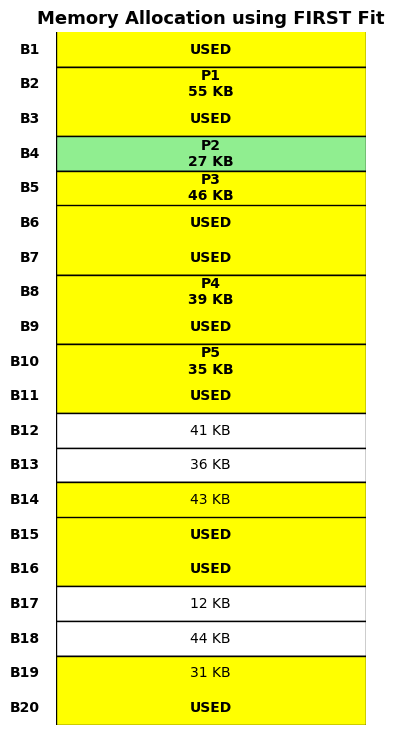


====== MEMORY ALLOCATION MENU ======
1. First Fit
2. Best Fit
3. Worst Fit
4. Exit


In [ ]:
import matplotlib.pyplot as plt

# ---------- INITIAL MEMORY CREATION ----------
n_blocks = int(input("Enter number of blocks: "))
n_files = int(input("Enter number of files: "))

block_status = []
block_sizes = []
file_sizes = []

# take block details from user
print("\nEnter Block Details")
print("0 = FREE , 1 = USED")

for i in range(n_blocks):
    status = int(input(f"Enter status for Block B{i+1}: "))

    block_status.append(status)

    if status == 0:
        size = int(input(f"Enter size of FREE Block B{i+1} (KB): "))
        block_sizes.append(size)
    else:
        block_sizes.append(0)

# take file sizes from user
print("\nEnter File Sizes")

for i in range(n_files):
    size = int(input(f"Enter size of File P{i+1} (KB): "))
    file_sizes.append(size)

# ---------- DISPLAY INITIAL BLOCK CONFIGURATION ----------
print("\nINITIAL MEMORY CONFIGURATION")
print("Block_no\tStatus\tBlock_size")

for i in range(n_blocks):
    status = "USED" if block_status[i] == 1 else "FREE"
    size = block_sizes[i] if block_status[i] == 0 else "-"
    print(f"B{i+1}\t\t{status}\t{size}")

print("\nFILE SIZES")
print("File_no\tFile_size")

for i in range(n_files):
    print(f"P{i+1}\t{file_sizes[i]}")

# ---------- FUNCTION : ALLOCATION ----------
def allocate_memory(method):

    allocation = [-1] * n_files
    fragment = [0] * n_files
    used = [False] * n_blocks

    free_blocks = [(block_sizes[i], i)
                   for i in range(n_blocks)
                   if block_status[i] == 0]

    if method == "best":
        free_blocks.sort()

    elif method == "worst":
        free_blocks.sort(reverse=True)

    # ---------- ALLOCATION ----------
    for i in range(n_files):

        for size, idx in free_blocks:

            if size >= file_sizes[i] and not used[idx]:

                allocation[i] = idx
                fragment[i] = size - file_sizes[i]
                used[idx] = True
                break

    # ---------- OUTPUT ----------
    print(f"\nAllocation using {method.upper()} FIT")
    print("File_no\tFile_size\tBlock_no\tBlock_size\tFragment")

    for i in range(n_files):

        if allocation[i] != -1:

            b = allocation[i]

            print(f"P{i+1}\t{file_sizes[i]}\t\tB{b+1}\t\t{block_sizes[b]}\t\t{fragment[i]}")

        else:
            print(f"P{i+1}\t{file_sizes[i]}\t\tNA\t\tNA\t\tNA")

    # ---------- BLOCK TO FILE MAP ----------
    block_to_file = {}

    for i, b in enumerate(allocation):
        if b != -1:
            block_to_file[b] = f"P{i+1}"

    # ---------- MEMORY VISUALIZATION ----------
    fig, ax = plt.subplots(figsize=(4, 9))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_blocks)
    ax.axis("off")

    for i in range(n_blocks):

        y = n_blocks - i - 1

        ax.text(-0.05, y + 0.5, f"B{i+1}",
                ha="right", va="center", weight="bold")

        if block_status[i] == 1:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="yellow", ec="black")
            )

            ax.text(0.5, y + 0.5, "USED",
                    ha="center", va="center", weight="bold")

        elif used[i]:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="lightgreen", ec="black")
            )

            ax.text(0.5, y + 0.5,
                    f"{block_to_file[i]}\n{block_sizes[i]} KB",
                    ha="center", va="center", weight="bold")

        else:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="white", ec="black")
            )

            ax.text(0.5, y + 0.5,
                    f"{block_sizes[i]} KB",
                    ha="center", va="center")

    ax.set_title(f"Memory Allocation using {method.upper()} Fit",
                 fontsize=13, fontweight="bold")

    plt.show()


# ---------- MENU ----------
while True:

    print("\n====== MEMORY ALLOCATION MENU ======")
    print("1. First Fit")
    print("2. Best Fit")
    print("3. Worst Fit")
    print("4. Exit")

    choice = int(input("Enter your choice: "))

    if choice == 1:
        allocate_memory("first")

    elif choice == 2:
        allocate_memory("best")

    elif choice == 3:
        allocate_memory("worst")

    elif choice == 4:
        print("Exiting Program...")
        break

    else:
        print("Invalid Choice!")

In [ ]:
# NOT RANDOM. INPUT CODE #

Enter number of blocks: 20
Enter number of files: 5

Enter Block Details
0 = FREE , 1 = USED
Enter status for Block B1: 0
Enter size of FREE Block B1 (KB): 41
Enter status for Block B2: 0
Enter size of FREE Block B2 (KB): 29
Enter status for Block B3: 0
Enter size of FREE Block B3 (KB): 28
Enter status for Block B4: 0
Enter size of FREE Block B4 (KB): 15
Enter status for Block B5: 1
Enter status for Block B6: 0
Enter size of FREE Block B6 (KB): 27
Enter status for Block B7: 1
Enter status for Block B8: 0
Enter size of FREE Block B8 (KB): 57
Enter status for Block B9: 0
Enter size of FREE Block B9 (KB): 22
Enter status for Block B10: 0
Enter size of FREE Block B10 (KB): 49
Enter status for Block B11: 0
Enter size of FREE Block B11 (KB): 49
Enter status for Block B12: 1
Enter status for Block B13: 0
Enter size of FREE Block B13 (KB): 10
Enter status for Block B14: 0
Enter size of FREE Block B14 (KB): 1
Enter status for Block B15: 1
Enter status for Block B16: 0
Enter size of FREE Block B

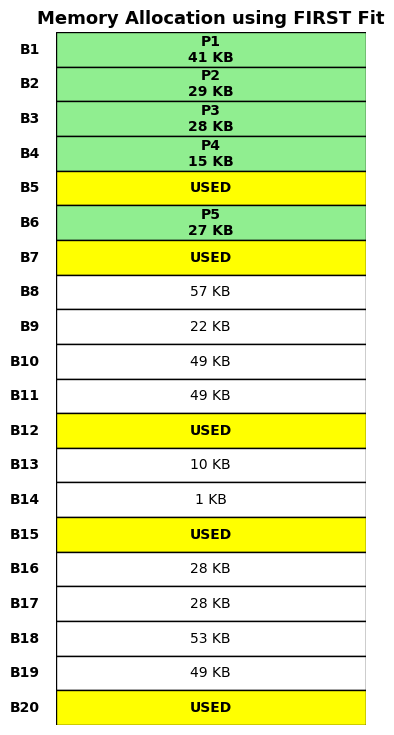


====== MEMORY ALLOCATION MENU ======
1. First Fit
2. Best Fit
3. Worst Fit
4. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
import matplotlib.pyplot as plt

# ---------- INITIAL MEMORY CREATION ----------
n_blocks = int(input("Enter number of blocks: "))
n_files = int(input("Enter number of files: "))

block_status = []
block_sizes = []
file_sizes = []

# take block details from user
print("\nEnter Block Details")
print("0 = FREE , 1 = USED")

for i in range(n_blocks):
    status = int(input(f"Enter status for Block B{i+1}: "))

    block_status.append(status)

    if status == 0:
        size = int(input(f"Enter size of FREE Block B{i+1} (KB): "))
        block_sizes.append(size)
    else:
        block_sizes.append(0)

# take file sizes from user
print("\nEnter File Sizes")

for i in range(n_files):
    size = int(input(f"Enter size of File P{i+1} (KB): "))
    file_sizes.append(size)

# ---------- DISPLAY INITIAL BLOCK CONFIGURATION ----------
print("\nINITIAL MEMORY CONFIGURATION")
print("Block_no\tStatus\tBlock_size")

for i in range(n_blocks):
    status = "USED" if block_status[i] == 1 else "FREE"
    size = block_sizes[i] if block_status[i] == 0 else "-"
    print(f"B{i+1}\t\t{status}\t{size}")

print("\nFILE SIZES")
print("File_no\tFile_size")

for i in range(n_files):
    print(f"P{i+1}\t{file_sizes[i]}")

# ---------- FUNCTION : ALLOCATION ----------
def allocate_memory(method):

    allocation = [-1] * n_files
    fragment = [0] * n_files
    used = [False] * n_blocks

    free_blocks = []
    for i in range(n_blocks):
      if block_status[i] == 0:
          free_blocks.append((block_sizes[i], i))

    if method == "best":
        free_blocks.sort()

    elif method == "worst":
        free_blocks.sort(reverse=True)

    # ---------- ALLOCATION ----------
    for i in range(n_files):

        for size, idx in free_blocks:

            if size >= file_sizes[i] and not used[idx]:

                allocation[i] = idx
                fragment[i] = size - file_sizes[i]
                used[idx] = True
                break

    # ---------- OUTPUT ----------
    print(f"\nAllocation using {method.upper()} FIT")
    print("File_no\tFile_size\tBlock_no\tBlock_size\tFragment")

    for i in range(n_files):

        if allocation[i] != -1:

            b = allocation[i]

            print(f"P{i+1}\t{file_sizes[i]}\t\tB{b+1}\t\t{block_sizes[b]}\t\t{fragment[i]}")

        else:
            print(f"P{i+1}\t{file_sizes[i]}\t\tNA\t\tNA\t\tNA")

    # ---------- BLOCK TO FILE MAP ----------

    block_to_file = {}

    for i, b in enumerate(allocation):
        if b != -1:
            block_to_file[b] = f"P{i+1}"

    # ---------- MEMORY VISUALIZATION ----------
    fig, ax = plt.subplots(figsize=(4, 9))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_blocks)
    ax.axis("off")

    for i in range(n_blocks):

        y = n_blocks - i - 1

        ax.text(-0.05, y + 0.5, f"B{i+1}",
                ha="right", va="center", weight="bold")

        if block_status[i] == 1:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="yellow", ec="black")
            )

            ax.text(0.5, y + 0.5, "USED",
                    ha="center", va="center", weight="bold")

        elif used[i]:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="lightgreen", ec="black")
            )

            ax.text(0.5, y + 0.5,
                    f"{block_to_file[i]}\n{block_sizes[i]} KB",
                    ha="center", va="center", weight="bold")

        else:

            ax.add_patch(
                plt.Rectangle((0, y), 1, 1,
                              color="white", ec="black")
            )

            ax.text(0.5, y + 0.5,
                    f"{block_sizes[i]} KB",
                    ha="center", va="center")

    ax.set_title(f"Memory Allocation using {method.upper()} Fit",
                 fontsize=13, fontweight="bold")

    plt.show()


# ---------- MENU ----------
while True:

    print("\n====== MEMORY ALLOCATION MENU ======")
    print("1. First Fit")
    print("2. Best Fit")
    print("3. Worst Fit")
    print("4. Exit")

    choice = int(input("Enter your choice: "))

    if choice == 1:
        allocate_memory("first")

    elif choice == 2:
        allocate_memory("best")

    elif choice == 3:
        allocate_memory("worst")

    elif choice == 4:
        print("Exiting Program...")
        break

    else:
        print("Invalid Choice!")2